In [25]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [26]:
try:
  connect = sqlite3.connect('data/checking-logs.sqlite')
  print('OK. Connected to sqlite')

except sqlite3.Error as error:
  print('Error with connection:', error)

OK. Connected to sqlite


In [30]:
query = '''
SELECT uid, timestamp
FROM checker
WHERE uid LIKE 'user_%'
'''
commits = pd.io.sql.read_sql(query, connect, parse_dates=['timestamp'])
commits

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:35.249331
2,user_4,2020-04-17 05:22:45.549397
3,user_4,2020-04-17 05:34:14.691200
4,user_4,2020-04-17 05:34:24.422370
...,...,...
3202,user_1,2020-05-21 20:19:06.872761
3203,user_1,2020-05-21 20:22:41.785725
3204,user_1,2020-05-21 20:22:41.877806
3205,user_1,2020-05-21 20:37:00.129678


In [32]:
commits['weekday'] = commits['timestamp'].dt.weekday
commits['hour'] = commits.timestamp.dt.hour
commits['type'] = commits['weekday'].apply(
    lambda x:'workday' if x <= 5 else 'weekend'
)
commits

,uid,timestamp,weekday,type,hour
0,user_4,2020-04-17 05:19:02.744528,4,workday,5
1,user_4,2020-04-17 05:22:35.249331,4,workday,5
2,user_4,2020-04-17 05:22:45.549397,4,workday,5
3,user_4,2020-04-17 05:34:14.691200,4,workday,5
4,user_4,2020-04-17 05:34:24.422370,4,workday,5
...,...,...,...,...,...
3202,user_1,2020-05-21 20:19:06.872761,3,workday,20
3203,user_1,2020-05-21 20:22:41.785725,3,workday,20
3204,user_1,2020-05-21 20:22:41.877806,3,workday,20
3205,user_1,2020-05-21 20:37:00.129678,3,workday,20


In [34]:
result = commits.groupby(['type','hour']).agg({'uid':'count'})
result.reset_index(inplace=True)
result

,type,hour,uid
0,weekend,0,6
1,weekend,1,6
2,weekend,5,2
3,weekend,7,2
4,weekend,8,19
5,weekend,9,17
6,weekend,10,27
7,weekend,11,26
8,weekend,12,29
9,weekend,13,77


In [81]:
pivot_table = pd.pivot(
    result,
    values='uid',
    index = 'hour',
    columns = 'type'
)
pivot_table

type,weekend,workday
hour,,
0,6.0,6.0
1,6.0,NaN
3,NaN,3.0
5,2.0,15.0
6,NaN,3.0
7,2.0,45.0
8,19.0,46.0
9,17.0,35.0
10,27.0,133.0


<Axes: title={'center': 'Commits per hour'}, ylabel='Frequency'>

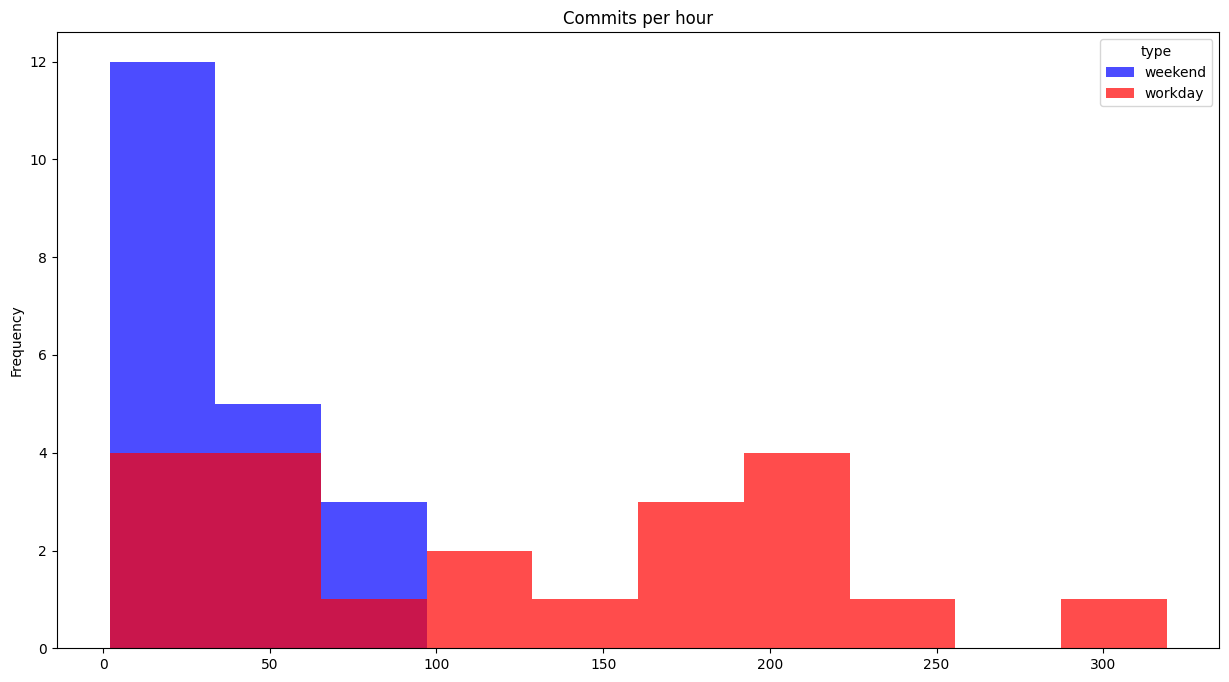

In [82]:
pivot_table.plot(
    kind = 'hist',
    figsize=(15,8),
    fontsize=10,
    title='Commits per hour',
    rot=0,
    alpha=0.7,
    subplots = False,
    color=('blue','red')
)


In [10]:
connect.close()